In [1]:
import os
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

os.chdir('/hpc/scratch/977879/roman_urdu_sentiment')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("All libraries imported successfully")
print("Device:", device)

All libraries imported successfully
Device: cuda


In [2]:
tokenizer = AutoTokenizer.from_pretrained('xlmroberta_finetuned')
model = AutoModelForSequenceClassification.from_pretrained('xlmroberta_finetuned')
model = model.to(device)
model.eval()

print("Model loaded successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully


In [3]:
df_emotion = pd.read_excel('RU-EN-Emotion Dataset.xlsx')

print(df_emotion.shape)
print(df_emotion.columns.tolist())
print(df_emotion.head())

(20000, 4)
['Unnamed: 0', 'Tweets', 'Level 1', 'Level 2']
   Unnamed: 0                                             Tweets  Level 1  \
0           0              yeh fair game nai thi I don’t like it  emotion   
1           1  Nasir mama ban gya aur jija ji hinduo ko bol r...  emotion   
2           2  : Part - #MissionMuzaffarabad #MasterShifujisM...  emotion   
3           3  O bhai ghoor se daikho vehicle parking ki wjah...  emotion   
4           4  Yeah hy hi ghatia so kbhi serious na lo is chu...  emotion   

  Level 2  
0   Anger  
1   Anger  
2   Anger  
3   Anger  
4   Anger  


In [4]:
print(df_emotion['Level 2'].value_counts())

Level 2
Neutral     11629
Happy        3720
Anger        3487
Sad           712
Fear          228
Surprise      224
Name: count, dtype: int64


In [5]:
emotion_map = {
    'Happy': 1,
    'Anger': 0,
    'Sad': 0,
    'Fear': 0
}

df_stress = df_emotion[df_emotion['Level 2'].isin(emotion_map.keys())].copy()
df_stress['sentiment'] = df_stress['Level 2'].map(emotion_map)
df_stress = df_stress.reset_index(drop=True)

print(df_stress.shape)
print(df_stress['sentiment'].value_counts())
print(df_stress['Level 2'].value_counts())

(8147, 5)
sentiment
0    4427
1    3720
Name: count, dtype: int64
Level 2
Happy    3720
Anger    3487
Sad       712
Fear      228
Name: count, dtype: int64


In [6]:
class StressTestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }

stress_dataset = StressTestDataset(df_stress['Tweets'].values, tokenizer)
stress_loader = DataLoader(stress_dataset, batch_size=16, shuffle=False)

all_preds = []

with torch.no_grad():
    for batch in stress_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

df_stress['predicted'] = all_preds

print(classification_report(df_stress['sentiment'], df_stress['predicted'], target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.86      0.79      0.82      4427
    Positive       0.77      0.84      0.80      3720

    accuracy                           0.81      8147
   macro avg       0.81      0.82      0.81      8147
weighted avg       0.82      0.81      0.81      8147



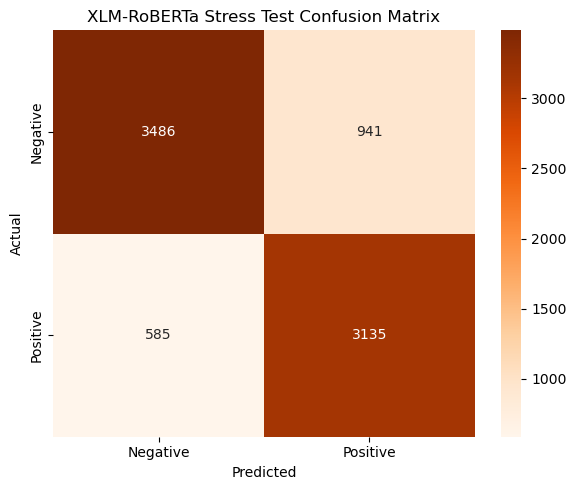

In [7]:
cm = confusion_matrix(df_stress['sentiment'], df_stress['predicted'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('XLM-RoBERTa Stress Test Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('StressTest_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
df_stress['original_label'] = df_stress['Level 2']
df_stress['correct'] = df_stress['sentiment'] == df_stress['predicted']

misclassified = df_stress[df_stress['correct'] == False][['Tweets', 'original_label', 'sentiment', 'predicted']].reset_index(drop=True)

misclassified.columns = ['Text', 'Emotion', 'Actual_Sentiment', 'Predicted_Sentiment']
misclassified['Actual_Sentiment'] = misclassified['Actual_Sentiment'].map({0: 'Negative', 1: 'Positive'})
misclassified['Predicted_Sentiment'] = misclassified['Predicted_Sentiment'].map({0: 'Negative', 1: 'Positive'})

misclassified.to_csv('misclassified_examples.csv', index=False)

print("Total misclassified:", len(misclassified))
print(misclassified.head(10))

Total misclassified: 1526
                                                Text Emotion Actual_Sentiment  \
0  : Part - #MissionMuzaffarabad #MasterShifujisM...   Anger         Negative   
1  Pakistan me CNIC pe Money Transfer ki option h...   Anger         Negative   
2                                  Ok Bhai theek hai   Anger         Negative   
3          Tera store khula hai ,inhe soup pilane ko   Anger         Negative   
4         : Din mein CEA Sham mein CMs Jaye to kahan   Anger         Negative   
5  Felt like absolute trash these past few days. ...   Anger         Negative   
6  Muhtarama zara hosh k nakhon lo inkay sth kisi...   Anger         Negative   
7  Night duty pai hai...koi bhi karta reh like or...   Anger         Negative   
8  : Ye pulis ka cake lana ye sab goro pe suit ka...   Anger         Negative   
9  Sahir keh ke chale gye, "wo subah kabhi toh ay...   Anger         Negative   

  Predicted_Sentiment  
0            Positive  
1            Positive  
2         